# **Face Recognition Model Training**

Install libraries

In [2]:
!pip install mtcnn tensorflow pillow imgaug opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.5 MB/s eta 0:00:00


In [9]:
!pip install "numpy<2.0"

Import necessary libraries

In [10]:
# Import necessary libraries
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import os
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

# Fix for numpy 2.0 compatibility issue with imgaug
import imgaug.random_state
imgaug.random_state.np = np

ModuleNotFoundError: No module named 'imgaug.random_state'

## Extract Frames from Video

In [6]:
import cv2
import os

# 📁 Set your video file path
video_path = '/content/drive/MyDrive/Face_Dataset/kyle.mp4'
output_dir = '/content/drive/MyDrive/Face_Dataset/extracted_frames'
frame_interval = 5  # Extract every 5th frame

In [7]:
# Extract base name without extension
video_filename = os.path.splitext(os.path.basename(video_path))[0]

# Create output directory
output_dir += f'/{video_filename}'
os.makedirs(output_dir, exist_ok=True)

# Load video
cap = cv2.VideoCapture(video_path)

frame_id = 0
saved_frame_count = 0
success = True

print(f"Extracting every {frame_interval} frames from: {video_path}")

while success:
    success, frame = cap.read()
    if not success:
        break

    if frame_id % frame_interval == 0:
        saved_frame_count += 1
        frame_filename = f"{video_filename}_{saved_frame_count}.jpg"
        output_path = os.path.join(output_dir, frame_filename)
        cv2.imwrite(output_path, frame)

    frame_id += 1

cap.release()
print(f"Done! {saved_frame_count} frames saved in '{output_dir}' folder.")


Extracting every 5 frames from: /content/drive/MyDrive/Face_Dataset/kyle.mp4
Done! 207 frames saved in '/content/drive/MyDrive/Face_Dataset/extracted_frames/kyle' folder.


## Data Preprocessing
involves grayscale, face detection, face alignment & cropping, face partition, and resize partitions

In [2]:
import os
import random
import shutil
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

# --- Configuration ---
RAW_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames"
PROCESSED_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset"
TRAIN_RATIO = 0.8  # 80% for training, 20% for validation
MAX_IMAGES_PER_SUBJECT = 50

# These sizes are what your models will expect as input.
TARGET_SIZES = {
    "top": (112, 64),    # Width x Height
    "mid": (112, 56),
    "bottom": (112, 64)
}

# --- Augmentation Pipeline ---
# This will be applied ONLY to the training images
augmentation_pipeline = iaa.Sequential([
    iaa.Fliplr(0.5),  # Horizontal flip 50% of the time
    iaa.Multiply((0.8, 1.2), per_channel=0.2), # Brightness/contrast
    iaa.GaussianBlur(sigma=(0, 0.5)),
    iaa.Affine(rotate=(-8, 8), scale=(0.9, 1.1)) # Slight rotation and scaling
], random_order=True)


def create_output_dirs(base_path, subjects, partitions=["top", "mid", "bottom"]):
    """Creates the necessary directory structure."""
    for subject in subjects:
        for part in partitions:
            os.makedirs(os.path.join(base_path, part, subject), exist_ok=True)


def process_and_partition_face(image_np, detector):
    """Detects a face and returns the three landmark-based partitions."""
    faces = detector.detect_faces(image_np)
    if not faces:
        return None  # No face detected

    face_data = faces[0]  # Assume one face per image for simplicity
    x, y, width, height = face_data['box']

    # Ensure box coordinates are within image bounds
    x, y = max(0, x), max(0, y)

    landmarks = face_data['keypoints']

    # Convert to PIL image to crop the main face
    image_pil = Image.fromarray(image_np)
    cropped_face = image_pil.crop((x, y, x + width, y + height))

    # Get relative landmark coordinates
    left_eye_rel = (landmarks['left_eye'][0] - x, landmarks['left_eye'][1] - y)
    right_eye_rel = (landmarks['right_eye'][0] - x, landmarks['right_eye'][1] - y)
    mouth_left_rel = (landmarks['mouth_left'][0] - x, landmarks['mouth_left'][1] - y)
    mouth_right_rel = (landmarks['mouth_right'][0] - x, landmarks['mouth_right'][1] - y)

    # Calculate cut lines based on landmarks
    eye_level_y = (left_eye_rel[1] + right_eye_rel[1]) / 2
    mouth_level_y = (mouth_left_rel[1] + mouth_right_rel[1]) / 2

    # Add some padding to avoid cutting right through features
    cut_line_1 = int(eye_level_y + height * 0.10)
    cut_line_2 = int(mouth_level_y - height * 0.10)

    # Sanity checks for cut lines
    cut_line_1 = max(0, min(cut_line_1, height))
    cut_line_2 = max(0, min(cut_line_2, height))

    # Fallback if landmarks are weirdly positioned
    if cut_line_1 >= cut_line_2:
        print("Warning: Landmark-based cuts failed, using ratio-based fallback.")
        cut_line_1, cut_line_2 = int(height * 0.40), int(height * 0.65)

    face_width = cropped_face.width
    partitions = {
        "top": cropped_face.crop((0, 0, face_width, cut_line_1)),
        "mid": cropped_face.crop((0, cut_line_1, face_width, cut_line_2)),
        "bottom": cropped_face.crop((0, cut_line_2, face_width, height))
    }
    return partitions


def main():
    """Main function to run the dataset creation pipeline."""
    # --- 1. Cleanup and Setup ---
    if os.path.exists(PROCESSED_DATASET_PATH):
        print(f"Removing existing processed dataset at '{PROCESSED_DATASET_PATH}'")
        shutil.rmtree(PROCESSED_DATASET_PATH)

    print("Creating new directory structure...")
    train_path = os.path.join(PROCESSED_DATASET_PATH, "train")
    val_path = os.path.join(PROCESSED_DATASET_PATH, "val")
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(val_path, exist_ok=True)

    # --- 2. Identify Subjects and Split them ---
    all_subjects = [d for d in os.listdir(RAW_DATASET_PATH) if os.path.isdir(os.path.join(RAW_DATASET_PATH, d))]

    # IMPORTANT: Identify test subjects who will be completely held out
    test_subjects = [s for s in all_subjects if s.endswith("_test")]
    train_val_subjects = [s for s in all_subjects if not s.endswith("_test")]

    if not train_val_subjects:
        print("Error: No training subjects found. Please name your training folders without '_test' at the end.")
        return

    print(f"Found {len(train_val_subjects)} subjects for Training/Validation: {train_val_subjects}")
    print(f"Found {len(test_subjects)} subjects for held-out Testing: {test_subjects}")
    print("-" * 30)

    # Create directory structures for train and validation sets
    create_output_dirs(train_path, train_val_subjects)
    create_output_dirs(val_path, train_val_subjects)

    # Initialize the face detector
    print("Initializing MTCNN face detector...")
    detector = MTCNN()

    # --- 3. Process Images for Train/Val Subjects ---
    for subject in train_val_subjects:
        print(f"Processing subject: {subject}")
        subject_path = os.path.join(RAW_DATASET_PATH, subject)

         # Get all available image files
        all_image_files = [f for f in os.listdir(subject_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # LIMIT THE NUMBER OF IMAGES PER SUBJECT
        if len(all_image_files) > MAX_IMAGES_PER_SUBJECT:
            print(f"  - Subject has {len(all_image_files)} images. Randomly selecting {MAX_IMAGES_PER_SUBJECT}.")
            image_files_to_process = random.sample(all_image_files, MAX_IMAGES_PER_SUBJECT)
        else:
            print(f"  - Subject has {len(all_image_files)} images (within the limit).")
            image_files_to_process = all_image_files

        # Shuffle the selected files for random train/val split
        random.shuffle(image_files_to_process)
        split_index = int(len(image_files_to_process) * TRAIN_RATIO)
        train_files = image_files_to_process[:split_index]
        val_files = image_files_to_process[split_index:]

        # Process training files with augmentation
        for i, filename in enumerate(train_files):
            image_path = os.path.join(subject_path, filename)
            try:
                image_np = np.asarray(Image.open(image_path).convert('RGB'))
                partitions = process_and_partition_face(image_np, detector)
                if partitions:
                    for part_name, part_image in partitions.items():
                        resized_part = part_image.resize(TARGET_SIZES[part_name], Image.Resampling.LANCZOS)

                        # Apply augmentation
                        augmented_np = augmentation_pipeline(image=np.array(resized_part))
                        augmented_image = Image.fromarray(augmented_np)

                        # Save the augmented image
                        save_folder = os.path.join(train_path, part_name, subject)
                        augmented_image.save(os.path.join(save_folder, f"{i:03d}_{filename}"))
            except Exception as e:
                print(f"  - Could not process {image_path}: {e}")

        # Process validation files without augmentation
        print(f"  - Processing {len(val_files)} images for validation set...")
        for i, filename in enumerate(val_files):
            image_path = os.path.join(subject_path, filename)
            try:
                image_np = np.asarray(Image.open(image_path).convert('RGB'))
                partitions = process_and_partition_face(image_np, detector)
                if partitions:
                    for part_name, part_image in partitions.items():
                        resized_part = part_image.resize(TARGET_SIZES[part_name], Image.Resampling.LANCZOS)

                        # Save the original resized image (no augmentation)
                        save_folder = os.path.join(val_path, part_name, subject)
                        resized_part.save(os.path.join(save_folder, filename))
            except Exception as e:
                print(f"  - Could not process {image_path}: {e}")

    print("\n" + "=" * 50)
    print("Dataset processing complete!")
    print(f"Processed data saved in: '{PROCESSED_DATASET_PATH}'")
    print("You are now ready to train your three separate models on the 'top', 'mid', and 'bottom' folders within 'train' and 'val'.")
    print("=" * 50)



main()

Creating new directory structure...
Found 4 subjects for Training/Validation: ['Tom Cruise', 'Zac Efron', 'kyle', '.ipynb_checkpoints']
Found 1 subjects for held-out Testing: ['Robert Downey Jr_test']
------------------------------
Initializing MTCNN face detector...
Processing subject: Tom Cruise
  - Subject has 58 images. Randomly selecting 50.
  - Processing 10 images for validation set...
Processing subject: Zac Efron
  - Subject has 91 images. Randomly selecting 50.
  - Processing 10 images for validation set...
Processing subject: kyle
  - Subject has 204 images. Randomly selecting 50.
  - Processing 10 images for validation set...
Processing subject: .ipynb_checkpoints
  - Subject has 0 images (within the limit).
  - Processing 0 images for validation set...

Dataset processing complete!
Processed data saved in: '/content/drive/MyDrive/Face_Dataset/processed_dataset'
You are now ready to train your three separate models on the 'top', 'mid', and 'bottom' folders within 'train' an

## Model Training

In [25]:
import os
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
import numpy as np # Import numpy

# --- Configuration ---
PROCESSED_DATASET_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset"
BATCH_SIZE = 32
IMAGE_HEIGHT_WIDTH = (None, 112) # We'll set the height dynamically
NUM_EPOCHS = 25 # Start with a reasonable number of epochs
LEARNING_RATE = 0.001

# Define the partitions and their specific input shapes (Height, Width, Channels)
PARTITIONS_CONFIG = {
    "top": {"shape": (64, 112, 3)},
    "mid": {"shape": (56, 112, 3)},
    "bottom": {"shape": (64, 112, 3)}
}

# --- MobileFaceNet Architecture (Simplified for this example) ---
# In a real project, you would import a proven MobileFaceNet implementation.
# This is a simplified representation to show the structure.
def build_mobilefacenet(input_shape, num_classes, model_name):
    """
    Builds a Keras Functional API model based on the MobileFaceNet architecture.
    """
    def _bottleneck(inputs, filters, kernel, t, s, r=False):
        # This is a simplified inverted residual block
        tchannel = tf.keras.backend.int_shape(inputs)[-1] * t
        x = layers.Conv2D(tchannel, 1, padding='same', use_bias=False)(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU(6.)(x)

        x = layers.DepthwiseConv2D(kernel, strides=s, depth_multiplier=1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU(6.)(x)

        x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)

        if r:
            x = layers.add([x, inputs])
        return x

    inputs = Input(shape=input_shape)

    # First layer
    x = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(6.)(x)

    # Inverted Residual Blocks (this is a simplified sequence)
    x = _bottleneck(x, 64, (3, 3), t=2, s=1, r=False)
    x = _bottleneck(x, 64, (3, 3), t=2, s=2, r=False)
    x = _bottleneck(x, 64, (3, 3), t=2, s=1, r=True)

    x = _bottleneck(x, 128, (3, 3), t=4, s=2, r=False)
    x = _bottleneck(x, 128, (3, 3), t=2, s=1, r=True)

    # Point-wise convolution and GDC
    x = layers.Conv2D(512, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(6.)(x)

    # GDC (Global Depthwise Convolution) Layer
    # The shape of kernel for DepthwiseConv2D depends on the shape of the input
    # Here, we get it dynamically
    kernel_size = (int(x.shape[1]), int(x.shape[2]))
    x = layers.DepthwiseConv2D(kernel_size, strides=(1, 1), depth_multiplier=1, padding='valid', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Final embedding and classification layers
    x = layers.Conv2D(128, 1, padding='same', use_bias=False)(x) # This is the 128-d embedding
    x = layers.Flatten()(x)

    # You can extract the embedding from the layer before the final dense layer
    # Define the output shape explicitly for the Lambda layer
    embedding = layers.Lambda(lambda x: x, output_shape=(128,), name="embedding")(x)

    # Classification head for training
    output = layers.Dense(num_classes, activation='softmax', name='classifier')(embedding)

    model = Model(inputs, output, name=model_name)
    return model

# --- Data Loading Function ---
def load_data_for_partition(partition_path, image_size):
    """
    Loads a dataset from a directory for a specific partition.
    """
    dataset = tf.keras.utils.image_dataset_from_directory(
        partition_path,
        label_mode='int',
        image_size=image_size,
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    # Prefetch for performance
    return dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

# --- Main Training Loop ---
def main():
    # Loop through each partition type to train a separate model
    for part_name, config in PARTITIONS_CONFIG.items():
        print("\n" + "="*20 + f" Training Model for '{part_name}' Partition " + "="*20)

        train_dir = os.path.join(PROCESSED_DATASET_PATH, "train", part_name)
        val_dir = os.path.join(PROCESSED_DATASET_PATH, "val", part_name)

        # Check if directories exist
        if not os.path.isdir(train_dir) or not os.path.isdir(val_dir):
            print(f"Error: Directories for partition '{part_name}' not found. Please run the data processing script first.")
            continue

        # 1. Get number of classes and load data
        num_classes = len([name for name in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, name))])
        if num_classes == 0:
            print(f"Error: No subject folders found in '{train_dir}'.")
            continue

        print(f"Found {num_classes} classes (subjects).")
        input_shape = config["shape"]
        image_size = (input_shape[0], input_shape[1]) # Keras expects (height, width)

        train_dataset = load_data_for_partition(train_dir, image_size)
        val_dataset = load_data_for_partition(val_dir, image_size)

        # 2. Build the MobileFaceNet model
        model = build_mobilefacenet(
            input_shape=input_shape,
            num_classes=num_classes,
            model_name=f"MobileFaceNet_{part_name}"
        )
        model.summary()

        # 3. Compile the model
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # 4. Train the model
        print(f"\nStarting training for {part_name} model...")
        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=NUM_EPOCHS,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
            ]
        )

        # 5. Save the final trained model
        save_path = f"/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_{part_name}.h5"
        model.save(save_path)
        print(f"\n--- Model for '{part_name}' partition saved to '{save_path}' ---")


main()


==================== Training Model for 'top' Partition ====================
Found 4 classes (subjects).
Found 120 files belonging to 3 classes.
Found 30 files belonging to 3 classes.


Model: "MobileFaceNet_top"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 64, 112,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (None, 32, 56,    │      1,728 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 56,    │        256 │ conv2d_78[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_72 (ReLU)     │ (None, 32, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 32, 56,    │      8,192 │ re_lu_72[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 56,    │        512 │ conv2d_79[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_73 (ReLU)     │ (None, 32, 56,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_36 │ (None, 32, 56,    │      1,152 │ re_lu_73[0][0]    │
│ (DepthwiseConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 56,    │        512 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_74 (ReLU)     │ (None, 32, 56,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 32, 56,    │      8,192 │ re_lu_74[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 56,    │        256 │ conv2d_80[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 32, 56,    │      8,192 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 56,    │        512 │ conv2d_81[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_75 (ReLU)     │ (None, 32, 56,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_37 │ (None, 16, 28,    │      1,152 │ re_lu_75[0][0]    │
│ (DepthwiseConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 28,    │        512 │ depthwise_conv2d

 Total params: 375,876 (1.43 MB)

 Trainable params: 369,220 (1.41 MB)

...

 Total params: 375,876 (1.43 MB)

 Trainable params: 369,220 (1.41 MB)

 Non-trainable params: 6,656 (26.00 KB)


Starting training for bottom model...
Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.3923 - loss: 1.8428 - val_accuracy: 0.3333 - val_loss: 1.3594
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9219 - loss: 0.1884 - val_accuracy: 0.3333 - val_loss: 1.3436
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9915 - loss: 0.0600 - val_accuracy: 0.3333 - val_loss: 1.3326
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9933 - loss: 0.0299 - val_accuracy: 0.3333 - val_loss: 1.3250
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 1.0000 - loss: 0.0168 - val_accuracy: 0.3333 - val_loss: 1.3194
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9915 - loss: 0.0163 - val_accuracy: 0.3333 - val_loss: 1.3166
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9946 - loss: 0.0183 - val_accuracy: 0.3333 - val_loss: 1.3148
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 


--- Model for 'bottom' partition saved to '/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_bottom.h5' ---


## Test Model

In [30]:
# Setup and Configuration
import os
import numpy as np
import tensorflow as tf
from PIL import Image
from mtcnn.mtcnn import MTCNN
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# --- Configuration ---
# Point these paths to your actual files in Google Drive or local storage
MODELS_PATH = {
    "top": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_top.h5",
    "mid": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_mid.h5",
    "bottom": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_bottom.h5"
}
GALLERY_SOURCE_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames"
PROCESSED_TRAIN_PATH = "/content/drive/MyDrive/Face_Dataset/processed_dataset/train"


# These must match the sizes used during training
TARGET_SIZES = {
    "top": (64, 112),    # Height x Width
    "mid": (56, 112),
    "bottom": (64, 112)
}

# Define the custom function used in the Lambda layer
# This needs to be defined in the scope where the model is loaded
def l2_normalize(x):
    return tf.math.l2_normalize(x, axis=1)

print("Setup complete.")

TensorFlow Version: 2.18.0
Setup complete.


In [31]:
# Load Models and Detector

# --- 1. Load the Trained Models ---
print("Loading trained models... (This may take a moment)")
models = {}
# The custom_objects dictionary tells Keras how to load the model with the custom Lambda layer
custom_objects = {'l2_normalize': l2_normalize}

for name, path in MODELS_PATH.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model file not found: {path}. Please train the models first.")

    # Load the full model
    full_model = tf.keras.models.load_model(path, custom_objects=custom_objects)

    # We need the embedding, not the final classifier output.
    # The embedding layer was named "embedding" in the training script.
    embedding_model = tf.keras.Model(
        inputs=full_model.input,
        outputs=full_model.get_layer("embedding").output,
        name=f"{name}_embedding_model"
    )
    models[name] = embedding_model
    print(f"  - Loaded '{name}' model.")
print("All models loaded successfully.")

# --- Initialize the face detector ---
print("\nInitializing MTCNN face detector...")
detector = MTCNN()
print("MTCNN detector ready.")

Loading trained models... (This may take a moment)


  - Loaded 'top' model.


  - Loaded 'mid' model.


  - Loaded 'bottom' model.
All models loaded successfully.

Initializing MTCNN face detector...
MTCNN detector ready.


In [41]:
# Define Helper Functions

def preprocess_and_partition(image_path, detector, target_sizes):
    """
    Loads an image, detects the face, and returns the three resized partitions.
    """
    try:
        image = Image.open(image_path).convert('RGB')
        image_np = np.asarray(image)
    except FileNotFoundError:
        # print(f"Error: Image not found at {image_path}")
        return None

    faces = detector.detect_faces(image_np)
    if not faces:
        # print(f"No face detected in {image_path}")
        return None

    face_data = faces[0]
    x, y, width, height = face_data['box']
    x, y = max(0, x), max(0, y)
    landmarks = face_data['keypoints']
    cropped_face = image.crop((x, y, x + width, y + height))

    # Re-use the same partitioning logic from your data creation script
    eye_level_y = (landmarks['left_eye'][0] - x + landmarks['right_eye'][0] - x) / 2 # Corrected to use x-coordinates for eye level
    mouth_level_y = (landmarks['mouth_left'][0] - x + landmarks['mouth_right'][0] - x) / 2 # Corrected to use x-coordinates for mouth level
    cut_line_1 = int(eye_level_y + height * 0.10)
    cut_line_2 = int(mouth_level_y - height * 0.10)
    cut_line_1 = max(0, min(cut_line_1, height))
    cut_line_2 = max(0, min(cut_line_2, height))
    if cut_line_1 >= cut_line_2:
        cut_line_1, cut_line_2 = int(height * 0.40), int(height * 0.65)

    face_width = cropped_face.width
    raw_partitions = {
        "top": cropped_face.crop((0, 0, face_width, cut_line_1)),
        "mid": cropped_face.crop((0, cut_line_1, face_width, cut_line_2)),
        "bottom": cropped_face.crop((0, cut_line_2, face_width, height))
    }

    # --- Add Visualization Here ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Face Partitions for {os.path.basename(image_path)}', fontsize=16)

    axes[0].imshow(cropped_face)
    axes[0].set_title("Cropped Face")
    axes[0].axis('off')

    axes[1].imshow(raw_partitions['top'])
    axes[1].set_title("Top Partition")
    axes[1].axis('off')

    axes[2].imshow(raw_partitions['mid'])
    axes[2].set_title("Mid Partition")
    axes[2].axis('off')

    axes[3].imshow(raw_partitions['bottom'])
    axes[3].set_title("Bottom Partition")
    axes[3].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    # --- End Visualization ---


    processed_partitions = {}
    for name, img in raw_partitions.items():
        resized_img = img.resize(target_sizes[name][::-1], Image.Resampling.LANCZOS)
        img_array = np.asarray(resized_img).astype('float32') / 255.0
        processed_partitions[name] = np.expand_dims(img_array, axis=0)
    return processed_partitions

def get_fused_embedding(image_path, models, detector, target_sizes):
    """
    Processes an image and returns a single fused embedding vector.
    """
    partitions = preprocess_and_partition(image_path, detector, target_sizes)
    if partitions is None:
        return None

    emb_top = models['top'].predict(partitions['top'], verbose=0)
    emb_mid = models['mid'].predict(partitions['mid'], verbose=0)
    emb_bottom = models['bottom'].predict(partitions['bottom'], verbose=0)

    fused_embedding = np.concatenate([emb_top, emb_mid, emb_bottom], axis=1)

    # L2 normalization of the final fused embedding
    norm = np.linalg.norm(fused_embedding)
    if norm == 0:
        return fused_embedding
    return fused_embedding / norm

print("Helper functions defined.")

Helper functions defined.


In [39]:
# Build the Gallery

print("\nBuilding gallery from known subjects...")
gallery_final = {}  # { "person_name": representative_embedding }

# Get subject names from one of the processed training directories
subjects = [d for d in os.listdir(os.path.join(PROCESSED_TRAIN_PATH, "top")) if os.path.isdir(os.path.join(PROCESSED_TRAIN_PATH, "top", d))]

for subject in subjects:
    print(f"  - Processing gallery images for: {subject}")
    subject_gallery_embeddings = []
    original_subject_path = os.path.join(GALLERY_SOURCE_PATH, subject)

    if not os.path.isdir(original_subject_path):
        print(f"    Warning: Original raw data path not found for subject '{subject}'. Skipping.")
        continue

    # Use a reasonable number of images for the gallery representation per subject
    all_image_files = [f for f in os.listdir(original_subject_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    gallery_images_to_use = all_image_files[:min(len(all_image_files), 20)]

    for filename in gallery_images_to_use:
        image_path = os.path.join(original_subject_path, filename)
        fused_emb = get_fused_embedding(image_path, models, detector, TARGET_SIZES)
        if fused_emb is not None:
            subject_gallery_embeddings.append(fused_emb)

    # Average the embeddings for each person to get one representative vector
    if subject_gallery_embeddings:
        gallery_final[subject] = np.mean(np.array(subject_gallery_embeddings), axis=0)
        print(f"    - Created representative embedding for {subject} (from {len(subject_gallery_embeddings)} images).")
    else:
        print(f"    - No processable images found for {subject}. Skipping.")

print("\nGallery built successfully.")


Building gallery from known subjects...
  - Processing gallery images for: Tom Cruise
    - Created representative embedding for Tom Cruise (from 20 images).
  - Processing gallery images for: Zac Efron
    - Created representative embedding for Zac Efron (from 20 images).
  - Processing gallery images for: kyle
    - Created representative embedding for kyle (from 20 images).
  - Processing gallery images for: .ipynb_checkpoints
    - No processable images found for .ipynb_checkpoints. Skipping.

Gallery built successfully.



===== Testing with Probe Image =====
Path: /content/drive/MyDrive/Face_Dataset/extracted_frames/kyle/kyle_1.jpg


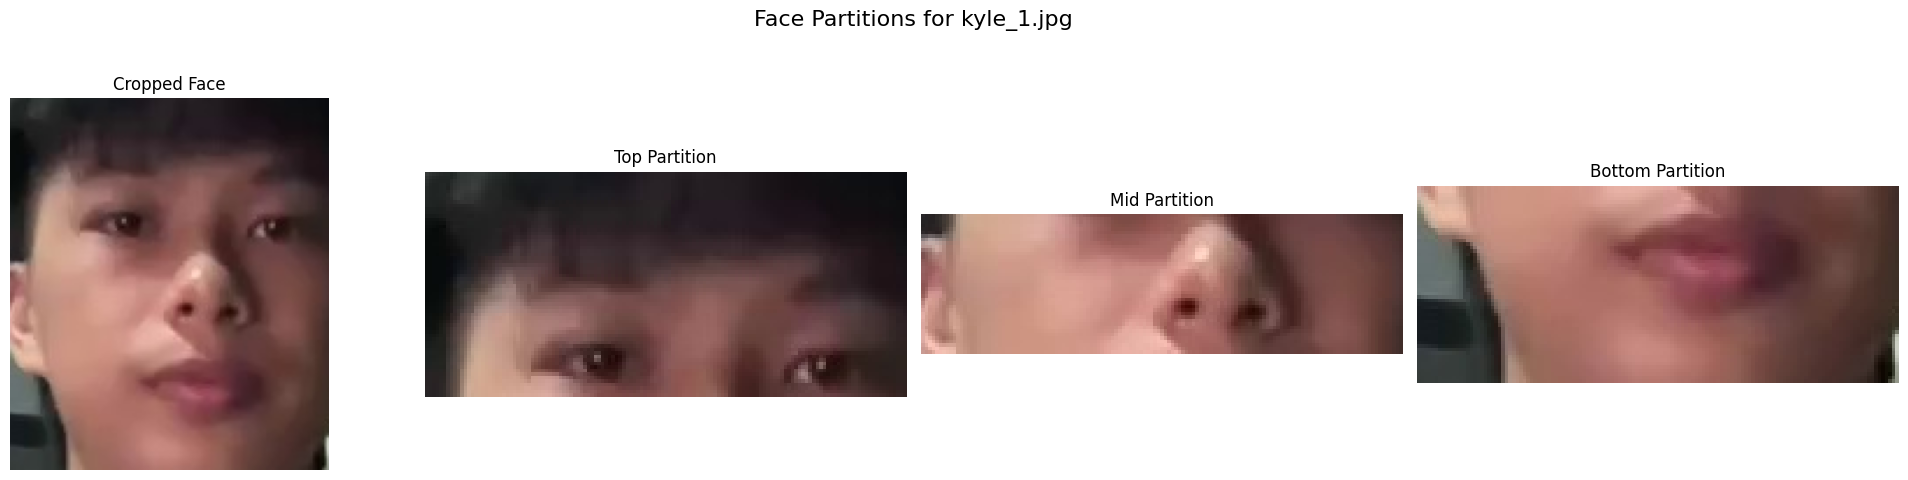


[Similarity Scores]

Debugging for Subject: Tom Cruise
Probe Embedding Shape: (1, 384)
Gallery Embedding Shape: (1, 384)
Sample Probe Embedding (first 10 values): [ 0.02795676  0.02639698  0.01110201 -0.06318726 -0.00046677  0.00733405
  0.00102188 -0.00102071 -0.02871925  0.0335774 ]
Sample Gallery Embedding (first 10 values): [ 0.0279573   0.02639803  0.01110161 -0.06318752 -0.00046637  0.00733479
  0.00102178 -0.00102106 -0.028719    0.03357694]
--------------------
  - vs Tom Cruise: 1.0000

Debugging for Subject: Zac Efron
Probe Embedding Shape: (1, 384)
Gallery Embedding Shape: (1, 384)
Sample Probe Embedding (first 10 values): [ 0.02795676  0.02639698  0.01110201 -0.06318726 -0.00046677  0.00733405
  0.00102188 -0.00102071 -0.02871925  0.0335774 ]
Sample Gallery Embedding (first 10 values): [ 0.02795731  0.02639811  0.01110153 -0.06318744 -0.00046631  0.00733484
  0.0010217  -0.00102109 -0.02871892  0.0335769 ]
--------------------
  - vs Zac Efron: 1.0000

Debugging for Subjec

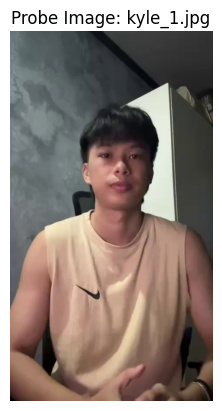

In [42]:
# Test a Probe Image

PROBE_IMAGE_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames/kyle/kyle_1.jpg"
# PROBE_IMAGE_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames/Robert Downey Jr_test/Robert Downey Jr_0.jpg"

print(f"\n===== Testing with Probe Image =====\nPath: {PROBE_IMAGE_PATH}")

probe_embedding = get_fused_embedding(PROBE_IMAGE_PATH, models, detector, TARGET_SIZES)

if probe_embedding is not None:
    best_match_name = "Unknown"
    best_match_score = -1  # Cosine similarity ranges from -1 to 1

    print("\n[Similarity Scores]")
    for subject, gallery_emb in gallery_final.items():
        # --- Debugging: Print embeddings before cosine calculation ---
        print(f"\nDebugging for Subject: {subject}")
        print("Probe Embedding Shape:", probe_embedding.shape)
        print("Gallery Embedding Shape:", gallery_emb.shape)
        print("Sample Probe Embedding (first 10 values):", probe_embedding.flatten()[:10])
        print("Sample Gallery Embedding (first 10 values):", gallery_emb.flatten()[:10])
        print("-" * 20)
        # --- End Debugging ---

        # Cosine distance is 1 - similarity. So similarity is 1 - distance.
        similarity = 1 - cosine(probe_embedding.flatten(), gallery_emb.flatten())
        print(f"  - vs {subject}: {similarity:.4f}")

        if similarity > best_match_score:
            best_match_score = similarity
            best_match_name = subject

    # --- Evaluate the Result ---
    print("\n--- PREDICTION ---")
    THRESHOLD = 0.5  # Adjust this threshold based on your results
    if best_match_score > THRESHOLD:
        print(f"✅ Match Found: '{best_match_name}' (Score: {best_match_score:.4f})")
    else:
        print(f"❌ Unknown Person. (Best match '{best_match_name}' was below threshold with score {best_match_score:.4f})")

    # --- Visualize the probe image ---
    try:
        probe_img = Image.open(PROBE_IMAGE_PATH)
        plt.imshow(probe_img)
        plt.title(f"Probe Image: {os.path.basename(PROBE_IMAGE_PATH)}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"\nCould not display probe image: {e}")

else:
    print("\n--- PREDICTION ---")
    print("❌ Could not process the probe image (e.g., no face detected).")

In [17]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image
from mtcnn.mtcnn import MTCNN
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

# --- Configuration ---
MODELS_PATH = {
    "top": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_top.h5",
    "mid": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_mid.h5",
    "bottom": "/content/drive/MyDrive/Face_Dataset/mobilefacenet_model_bottom.h5"
}
GALLERY_SOURCE_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames" # Use training data to build the gallery
PROBE_IMAGE_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames/Robert Downey Jr_test/Robert Downey Jr_0.jpg" # Example probe image of an UNKNOWN person
PROBE_IMAGE_PATH = "/content/drive/MyDrive/Face_Dataset/extracted_frames/kyle/kyle_1.jpg" # Example probe image of a KNOWN person

# These must match the sizes used during training
TARGET_SIZES = {
    "top": (64, 112),    # Height x Width
    "mid": (56, 112),
    "bottom": (64, 112)
}

# Define the custom function used in the Lambda layer
# This needs to be defined in the scope where the model is loaded
def l2_normalize(x):
    return tf.math.l2_normalize(x, axis=1)

# --- 1. Load the Trained Models ---
print("Loading trained models...")
models = {}
for name, path in MODELS_PATH.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model file not found: {path}. Please train the models first.")

    # Load the full model
    # custom_objects is needed to load the Lambda layer correctly
    full_model = tf.keras.models.load_model(path, custom_objects={'l2_normalize': l2_normalize})

    # We need the embedding, not the final classifier output.
    # The embedding layer was named "embedding" in the training script.
    embedding_model = tf.keras.Model(inputs=full_model.input, outputs=full_model.get_layer("embedding").output)
    models[name] = embedding_model
print("Models loaded successfully.")

# Initialize the face detector
detector = MTCNN()

# --- 2. Define Helper Functions ---
def preprocess_and_partition(image_path):
    """
    Loads an image, detects the face, and returns the three resized partitions.
    This combines logic from your data creation script.
    """
    try:
        image = Image.open(image_path).convert('RGB')
        image_np = np.asarray(image)
    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}")
        return None

    faces = detector.detect_faces(image_np)
    if not faces:
        print(f"No face detected in {image_path}")
        return None

    face_data = faces[0]
    x, y, width, height = face_data['box']
    x, y = max(0, x), max(0, y)

    landmarks = face_data['keypoints']

    cropped_face = image.crop((x, y, x + width, y + height))

    # Re-use the same partitioning logic from your data creation script
    left_eye_rel = (landmarks['left_eye'][0] - x, landmarks['left_eye'][1] - y)
    right_eye_rel = (landmarks['right_eye'][0] - x, landmarks['right_eye'][1] - y)
    mouth_left_rel = (landmarks['mouth_left'][0] - x, landmarks['mouth_left'][1] - y)
    mouth_right_rel = (landmarks['mouth_right'][0] - x, landmarks['mouth_right'][1] - y)

    eye_level_y = (left_eye_rel[1] + right_eye_rel[1]) / 2
    mouth_level_y = (mouth_left_rel[1] + mouth_right_rel[1]) / 2

    cut_line_1 = int(eye_level_y + height * 0.10)
    cut_line_2 = int(mouth_level_y - height * 0.10)

    cut_line_1 = max(0, min(cut_line_1, height))
    cut_line_2 = max(0, min(cut_line_2, height))

    if cut_line_1 >= cut_line_2:
        cut_line_1, cut_line_2 = int(height * 0.40), int(height * 0.65)

    face_width = cropped_face.width
    raw_partitions = {
        "top": cropped_face.crop((0, 0, face_width, cut_line_1)),
        "mid": cropped_face.crop((0, cut_line_1, face_width, cut_line_2)),
        "bottom": cropped_face.crop((0, cut_line_2, face_width, height))
    }

    # Resize and normalize partitions for the model
    processed_partitions = {}
    for name, img in raw_partitions.items():
        # PIL uses (W, H), TARGET_SIZES is (H, W)
        resized_img = img.resize(TARGET_SIZES[name][::-1], Image.Resampling.LANCZOS)
        img_array = np.asarray(resized_img).astype('float32') / 255.0
        processed_partitions[name] = np.expand_dims(img_array, axis=0) # Add batch dimension

    return processed_partitions

def get_fused_embedding(image_path):
    """
    Processes an image and returns a single fused embedding vector.
    """
    partitions = preprocess_and_partition(image_path)
    if partitions is None:
        return None

    # Get embedding for each partition
    emb_top = models['top'].predict(partitions['top'], verbose=0)
    emb_mid = models['mid'].predict(partitions['mid'], verbose=0)
    emb_bottom = models['bottom'].predict(partitions['bottom'], verbose=0)

    # Fusion strategy: Concatenation
    fused_embedding = np.concatenate([emb_top, emb_mid, emb_bottom], axis=1)

    # Normalize the final fused embedding
    fused_embedding = fused_embedding / np.linalg.norm(fused_embedding)

    return fused_embedding

# --- 3. Build the Gallery ---
print("\nBuilding gallery from training data...")
gallery_final = {} # { "person_name": [fused_embedding_for_this_person] }

# Get subject names from the processed dataset training directory (any partition will do)
subjects = [d for d in os.listdir(os.path.join("/content/drive/MyDrive/Face_Dataset/processed_dataset/train", "top")) if os.path.isdir(os.path.join("/content/drive/MyDrive/Face_Dataset/processed_dataset/train", "top", d))]

# Map processed subject names back to original raw data paths
# This assumes a structure like RAW_DATASET_PATH/subject_name/images...
# and PROCESSED_DATASET_PATH/train/partition/subject_name/images...
# We need to process the ORIGINAL images for the gallery.
raw_subjects_path = "/content/drive/MyDrive/Face_Dataset/extracted_frames" # Path to your raw extracted frames


for subject in subjects:
    if subject.startswith('.'): # Skip hidden directories like .ipynb_checkpoints
        continue

    print(f"  - Processing gallery images for: {subject}")
    subject_gallery_embeddings = []
    original_subject_path = os.path.join(raw_subjects_path, subject)

    if not os.path.isdir(original_subject_path):
        print(f"    Warning: Original raw data path not found for subject '{subject}' at '{original_subject_path}'. Skipping.")
        continue

    # Limit the number of images used for the gallery representation per subject
    all_image_files = [f for f in os.listdir(original_subject_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    # Use a reasonable number of images for the gallery representation
    gallery_images_to_use = all_image_files[:min(len(all_image_files), 20)] # Use up to 20 images

    for filename in gallery_images_to_use:
        image_path = os.path.join(original_subject_path, filename)
        fused_emb = get_fused_embedding(image_path)
        if fused_emb is not None:
            subject_gallery_embeddings.append(fused_emb)

    # Average the embeddings for each person to get one representative vector
    if subject_gallery_embeddings:
        gallery_final[subject] = np.mean(subject_gallery_embeddings, axis=0)
        print(f"    - Added representative embedding for {subject} (averaged {len(subject_gallery_embeddings)} images).")
    else:
         print(f"    - No processable images found for {subject}. Skipping.")


print("Gallery built successfully.")

# --- 4. Test a Probe Image ---
print(f"\nTesting with probe image: {PROBE_IMAGE_PATH}")
probe_embedding = get_fused_embedding(PROBE_IMAGE_PATH)

if probe_embedding is not None:
    best_match_name = None
    best_match_score = -1 # Cosine similarity ranges from -1 to 1

    print("\nSimilarity Scores:")
    for subject, gallery_emb in gallery_final.items():
        # Cosine distance is 1 - similarity. So similarity is 1 - distance.
        # Pass 1-D vectors to cosine function
        similarity = 1 - cosine(probe_embedding[0], gallery_emb[0])
        print(f"  - {subject}: {similarity:.4f}")

        if similarity > best_match_score:
            best_match_score = similarity
            best_match_name = subject

    # --- 5. Evaluate the Result ---
    print("\n--- TEST RESULT ---")
    # A common threshold for face recognition is around 0.5-0.6 for cosine similarity
    THRESHOLD = 0.5
    if best_match_score > THRESHOLD:
        print(f"Prediction: '{best_match_name}' with a similarity score of {best_match_score:.4f}")
    else:
        print(f"Prediction: Unknown Person (Best match '{best_match_name}' was below threshold with score {best_match_score:.4f})")

    # Visualize the probe image
    try:
        probe_img = Image.open(PROBE_IMAGE_PATH)
        plt.imshow(probe_img)
        plt.title(f"Probe Image: {os.path.basename(PROBE_IMAGE_PATH)}")
        plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print(f"Could not display probe image: {PROBE_IMAGE_PATH} not found.")


else:
    print("Could not process the probe image (no face detected).")

Loading trained models...


NotImplementedError: Exception encountered when calling Lambda.call().

[1mWe could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.[0m

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 128), dtype=float32, sparse=False, name=keras_tensor_1032>',)
  • kwargs={'mask': 'None'}

## Archives

In [ ]:
def process_and_save_partitions(image_path, output_folder="processed_data"):
    """
    Main function to detect, partition, resize, and augment a face from an image.
    """
    # --- Setup ---
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        os.makedirs(os.path.join(output_folder, "resized"))
        os.makedirs(os.path.join(output_folder, "augmented"))

    try:
        image = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}")
        return

    image_np = np.asarray(image)
    detector = MTCNN()
    faces = detector.detect_faces(image_np)

    if not faces:
        print("No face detected.")
        return

    # --- Detection and Cropping ---
    face_data = faces[0]
    x, y, width, height = face_data['box']
    landmarks = face_data['keypoints']
    cropped_face = image.crop((x, y, x + width, y + height))

    # --- Landmark-Based Partitioning ---
    left_eye_rel = (landmarks['left_eye'][0] - x, landmarks['left_eye'][1] - y)
    right_eye_rel = (landmarks['right_eye'][0] - x, landmarks['right_eye'][1] - y)
    mouth_left_rel = (landmarks['mouth_left'][0] - x, landmarks['mouth_left'][1] - y)
    mouth_right_rel = (landmarks['mouth_right'][0] - x, landmarks['mouth_right'][1] - y)

    eye_level_y = (left_eye_rel[1] + right_eye_rel[1]) / 2
    mouth_level_y = (mouth_left_rel[1] + mouth_right_rel[1]) / 2

    cut_line_1 = int(eye_level_y + height * 0.10)
    cut_line_2 = int(mouth_level_y - height * 0.10)

    cut_line_1 = max(0, min(cut_line_1, height))
    cut_line_2 = max(0, min(cut_line_2, height))

    if cut_line_1 >= cut_line_2:
        cut_line_1, cut_line_2 = int(height * 0.40), int(height * 0.65)

    face_width = cropped_face.width
    partitions = {
        "top": cropped_face.crop((0, 0, face_width, cut_line_1)),
        "mid": cropped_face.crop((0, cut_line_1, face_width, cut_line_2)),
        "bottom": cropped_face.crop((0, cut_line_2, face_width, height))
    }

    print("Partitions created successfully.")

    # --- Define Target Sizes for Each Partition ---
    # These sizes are what your models will expect as input.
    target_sizes = {
        "top": (112, 64),  # Width x Height
        "mid": (112, 56),
        "bottom": (112, 64)
    }

    # --- Process Each Partition ---
    base_filename = os.path.splitext(os.path.basename(image_path))[0]
    resized_partitions = {}

    for name, part_image in partitions.items():
        # --- 1. Resizing ---
        target_size = target_sizes[name]
        # Using LANCZOS for high-quality downsampling
        resized_image = part_image.resize(target_size, Image.Resampling.LANCZOS)
        resized_partitions[name] = resized_image # Store for visualization

        # Save the resized image
        resized_image.save(os.path.join(output_folder, "resized", f"{base_filename}_{name}_resized.jpg"))

        # --- 2. Simple Augmentation (Horizontal Flip) ---
        # Augment the RESIZED image
        augmented_image = augment_image(resized_image)
        augmented_image.save(os.path.join(output_folder, "augmented", f"{base_filename}_{name}_augmented_flip.jpg"))

    print(f"\nSaved resized and augmented partitions to the '{output_folder}' folder.")

    # --- Visualization (Great for Jupyter!) ---
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle('Original, Resized, and Augmented (Flipped) Partitions', fontsize=16)

    # Plotting Top Partition
    axes[0, 0].set_title("Original Top")
    axes[0, 0].imshow(partitions['top'])
    axes[0, 1].set_title(f"Resized Top\n{target_sizes['top'][0]}x{target_sizes['top'][1]}")
    axes[0, 1].imshow(resized_partitions['top'])
    axes[0, 2].set_title("Augmented (Flipped)")
    axes[0, 2].imshow(Image.open(os.path.join(output_folder, "augmented", f"{base_filename}_top_augmented_flip.jpg")))

    # Plotting Mid Partition
    axes[1, 0].set_title("Original Mid")
    axes[1, 0].imshow(partitions['mid'])
    axes[1, 1].set_title(f"Resized Mid\n{target_sizes['mid'][0]}x{target_sizes['mid'][1]}")
    axes[1, 1].imshow(resized_partitions['mid'])
    axes[1, 2].set_title("Augmented (Flipped)")
    axes[1, 2].imshow(Image.open(os.path.join(output_folder, "augmented", f"{base_filename}_mid_augmented_flip.jpg")))

    # Plotting Bottom Partition
    axes[2, 0].set_title("Original Bottom")
    axes[2, 0].imshow(partitions['bottom'])
    axes[2, 1].set_title(f"Resized Bottom\n{target_sizes['bottom'][0]}x{target_sizes['bottom'][1]}")
    axes[2, 1].imshow(resized_partitions['bottom'])
    axes[2, 2].set_title("Augmented (Flipped)")
    axes[2, 2].imshow(Image.open(os.path.join(output_folder, "augmented", f"{base_filename}_bottom_augmented_flip.jpg")))

    for ax_row in axes:
        for ax in ax_row:
            ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
def normalize_image(image_pil):
    """
    Normalizes a PIL image by converting it to a NumPy array,
    scaling pixel values to the [0, 1] range, and returning it.
    """
    image_np = np.asarray(image_pil).astype(np.float32)
    # Scale pixel values from [0, 255] to [0, 1]
    normalized_np = image_np / 255.0
    return normalized_np

def augment_image(image_pil):
    """
    Applies a simple horizontal flip augmentation.
    """
    # Convert PIL image to NumPy array for imgaug
    image_np = np.asarray(image_pil)

    # Define a simple augmentation sequence: just a horizontal flip
    seq = iaa.Sequential([
        iaa.Fliplr(1.0), # always flip horizontally for this example
    ])

    # Augment the image
    augmented_np = seq(image=image_np)

    # Convert back to PIL Image
    augmented_pil = Image.fromarray(augmented_np)

    return augmented_pil

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


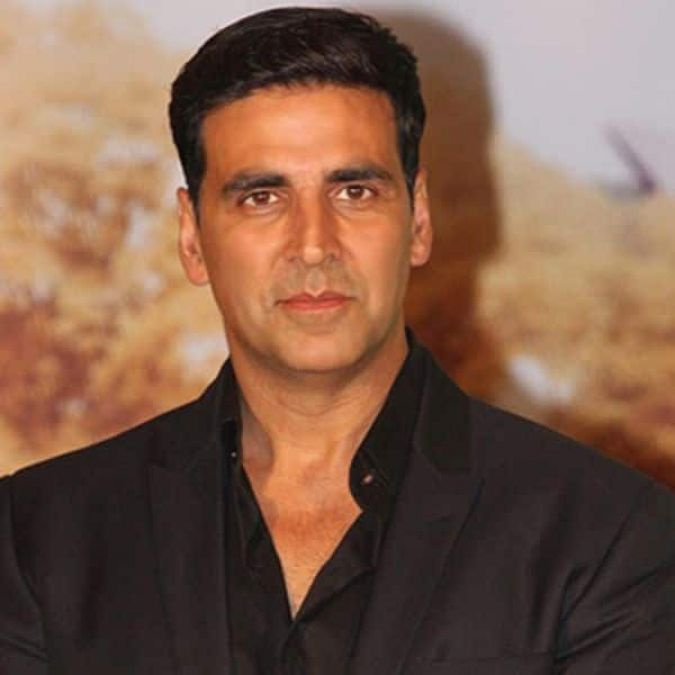

In [ ]:
from PIL import Image

input_image_path = "test_image.jpg"
image = Image.open(input_image_path)

# Display the image (optional)
image


Partitions created successfully.

Saved resized and augmented partitions to the 'processed_data' folder.


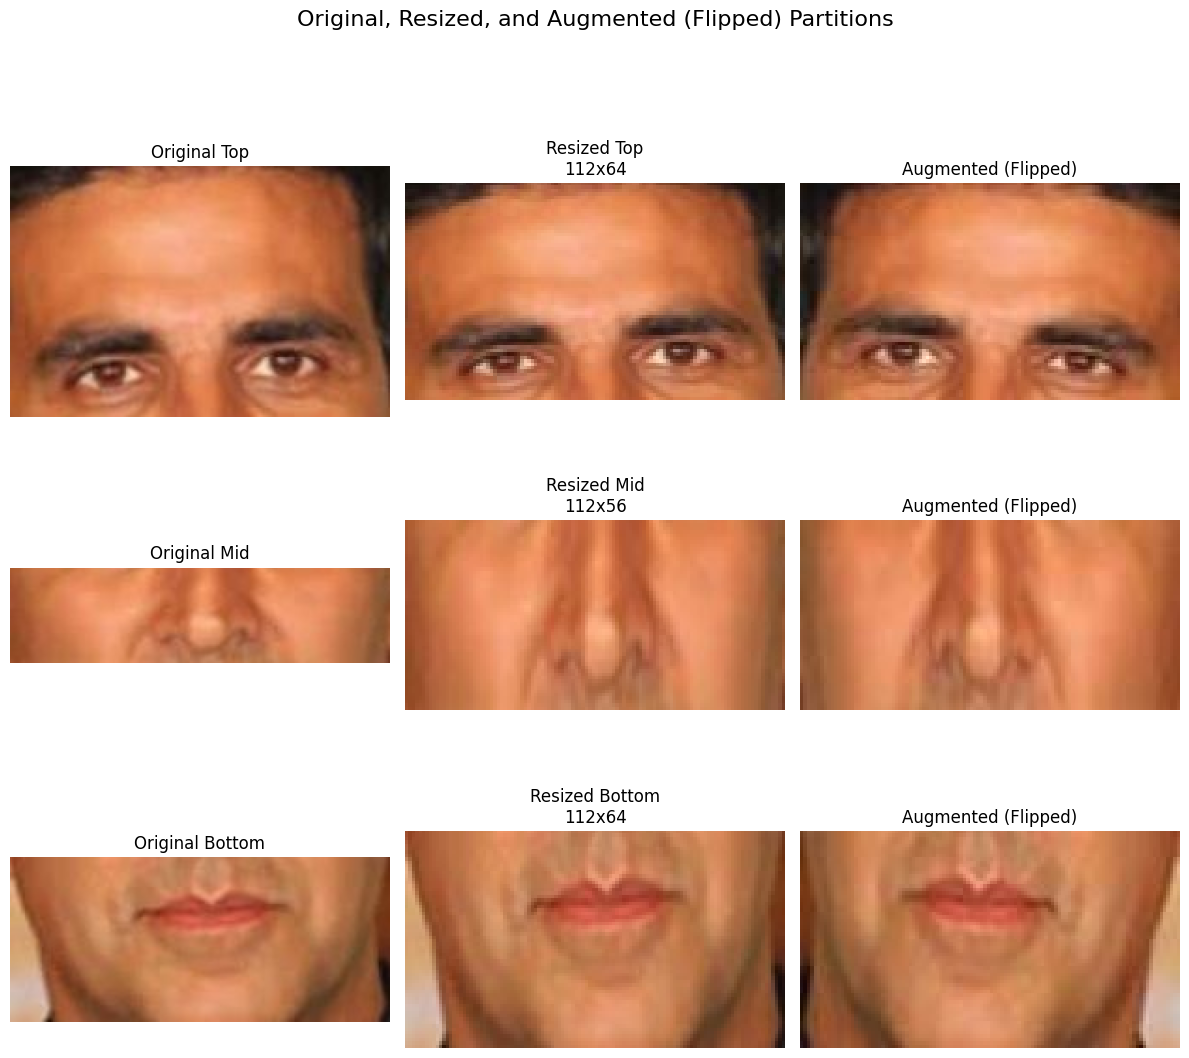

In [ ]:
process_and_save_partitions(input_image_path)

In [ ]:
# Define a sample image path
sample_image_path = "/content/drive/MyDrive/Face_Dataset/extracted_frames/kyle/kyle_1.jpg" # Replace with your image path

# Ensure necessary libraries are imported
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import matplotlib.pyplot as plt
import os

# Re-define or ensure preprocess_and_partition and detector are available
# (Assuming preprocess_and_partition and detector are defined in previous cells)

# Initialize the face detector if not already done
if 'detector' not in locals():
    detector = MTCNN()
    print("MTCNN detector initialized.")

# Define the target sizes used during preprocessing
# These should match the TARGET_SIZES in your data processing cell
TARGET_SIZES = {
    "top": (64, 112),    # Height x Width
    "mid": (56, 112),
    "bottom": (64, 112)
}

# Get the processed partitions
partitions = preprocess_and_partition(sample_image_path)

if partitions:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Face Partitions for {os.path.basename(sample_image_path)}', fontsize=16)

    axes[0].imshow(partitions['top'][0]) # Access the image from the batch dimension
    axes[0].set_title("Top Partition")
    axes[0].axis('off')

    axes[1].imshow(partitions['mid'][0]) # Access the image from the batch dimension
    axes[1].set_title("Mid Partition")
    axes[1].axis('off')

    axes[2].imshow(partitions['bottom'][0]) # Access the image from the batch dimension
    axes[2].set_title("Bottom Partition")
    axes[2].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print(f"Could not process {sample_image_path} to show partitions.")